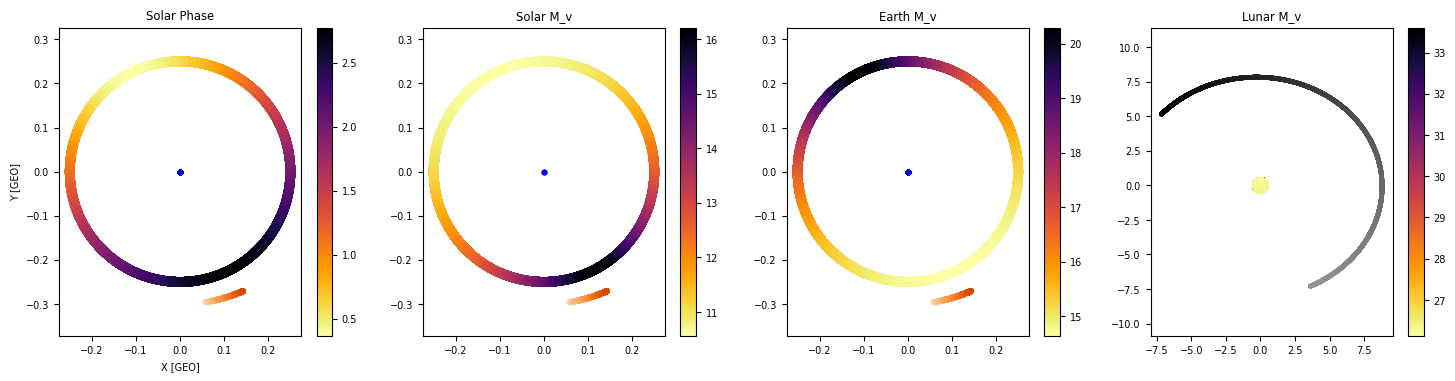

In [3]:
import yeager_utils as ut
import numpy as np
import matplotlib.pyplot as plt
import ssapy
from ssapy.body import get_body
from ssapy.constants import RGEO, MOON_RADIUS, EARTH_RADIUS


times = ut.get_times(duration=(15, 'days'), freq=(1, 'min'), t=ut.Time("2025-1-1"))
r_sun = get_body('Sun').position(times).T

r_moon = get_body('Moon').position(times).T
r, v = ssapy.rv(ssapy.Orbit.fromKeplerianElements(*[.25 * ut.RGEO, 0, 0, 0, 0, 0], t=times[0]), times, propagator=ssapy.RK78Propagator(ssapy.AccelKepler(), h=10.0))
Mv = ut.M_v_lambertian(r, times, radius=1, plot=True)


[   0.         3074.6599996   307.46599996] 3074.6599995993042


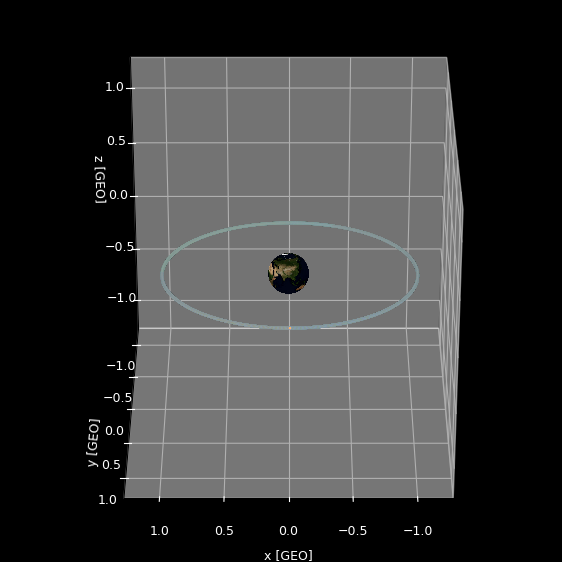

In [1]:
import ssapy
import yeager_utils as ut
import numpy as np
import matplotlib.pyplot as plt

from ssapy.accel import AccelKepler, AccelSolRad, AccelEarthRad, AccelDrag
from ssapy.body import get_body
from ssapy.gravity import AccelThirdBody, AccelHarmonic

times = ut.get_times(duration=(25, 'days'), freq=(1, 'min'), t=ut.Time("2025-3-20"))
r_sun = ssapy.get_body('Sun').position(times).T
r_moon = ssapy.get_body('Moon').position(times).T

sat = dict(
    mass=500,  # [kg] --> was 1e4
    area=.022,  # [m^2]
    CD=2.3,  # Drag coefficient
    CR=1.3,  # Radiation pressure coefficient
)

peri = ut.EARTH_RADIUS + 5000e3
ap = ut.RGEO
a = (peri + ap) / 2
e = (ap - peri)/ (ap + peri)
a = ut.RGEO
e = 0
i = np.radians(0)
pa = np.radians(0)
raan = np.radians(0)
ta = np.radians(0)

#Initializing an orbit in ITRF?
orbit = ssapy.Orbit.fromKeplerianElements(*[a, e, i, pa, raan, ta], t=times[0], propkw=sat)
r0 = orbit.r
v0 = orbit.v
v0 = v0 + [0, 0, ut.VGEO/10]
print(v0, ut.VGEO)
r, v = ssapy.rv(ssapy.Orbit(r=r0, v=v0, t=times[0]), times, propagator=ssapy.RK78Propagator(AccelKepler(), h=10.0))



ut.globe_plot(r, times[:len(r)], title=f"Model: Kepler", az=90)
plt.show()


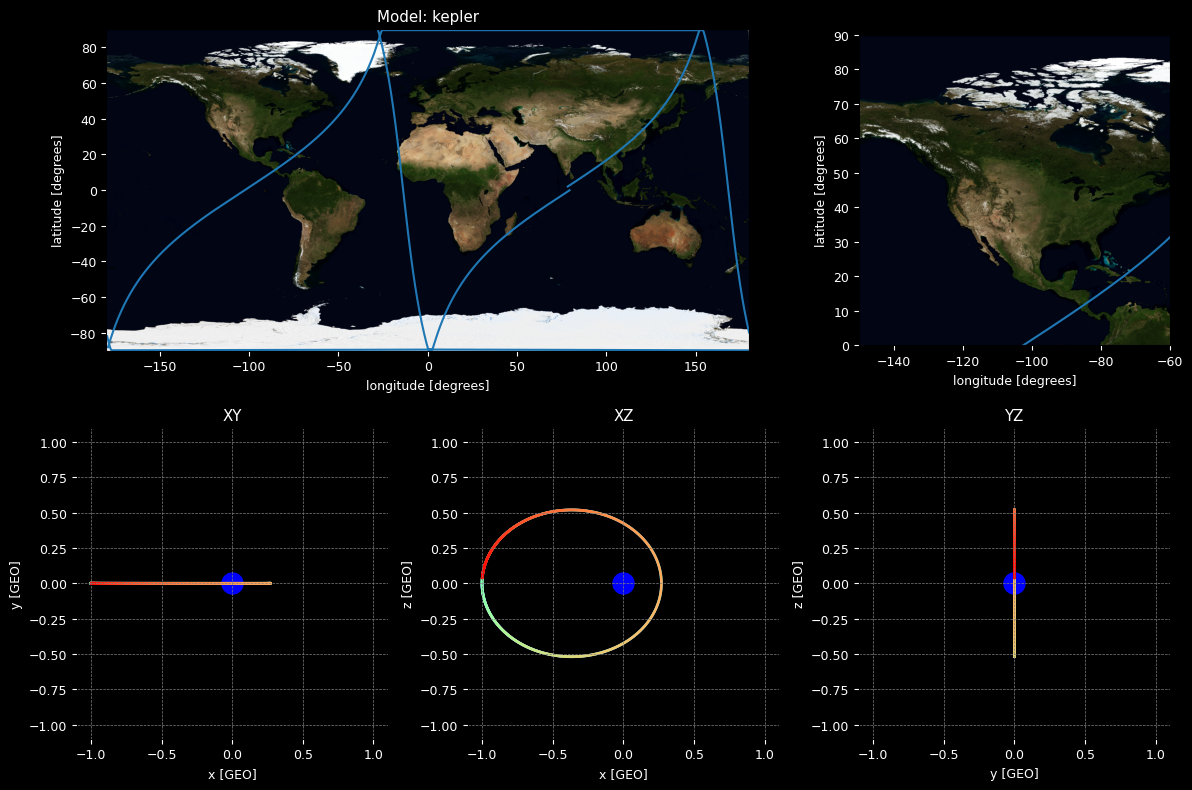

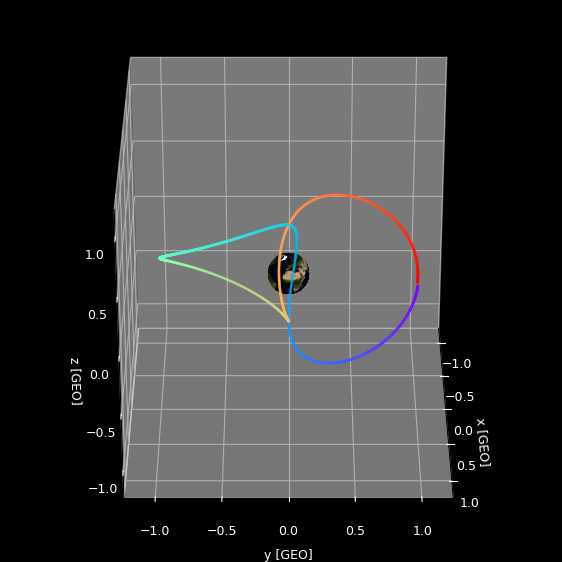

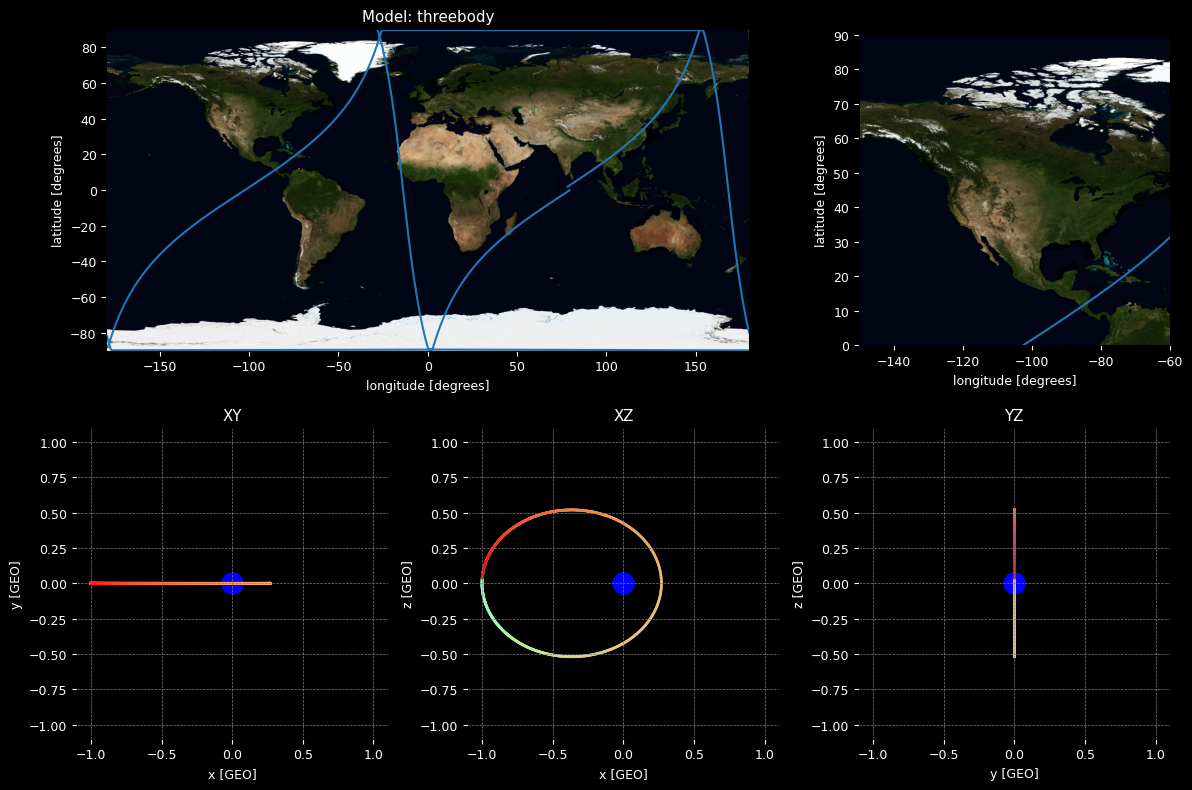

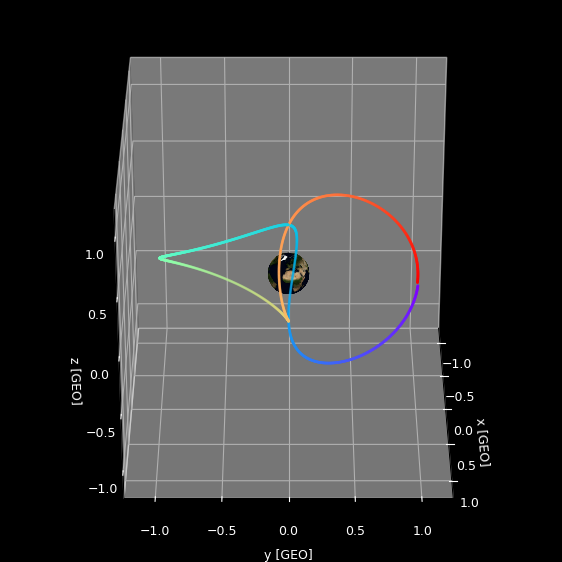

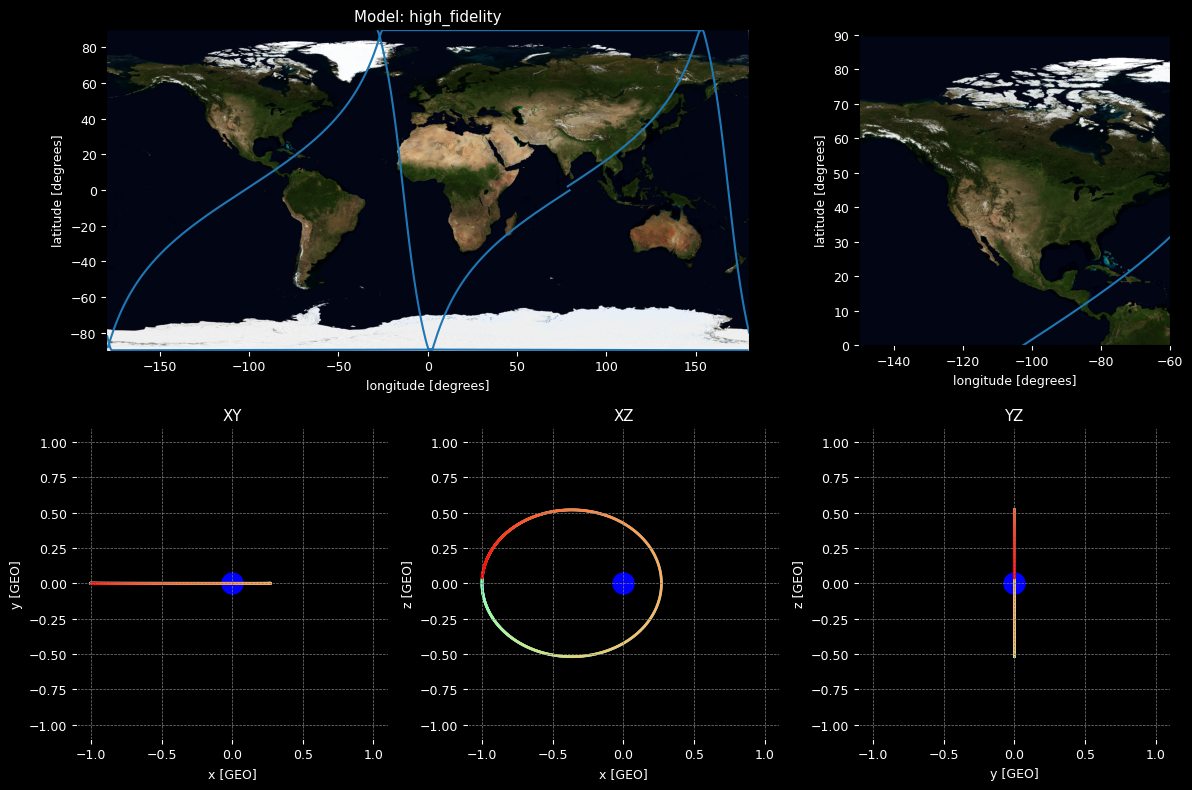

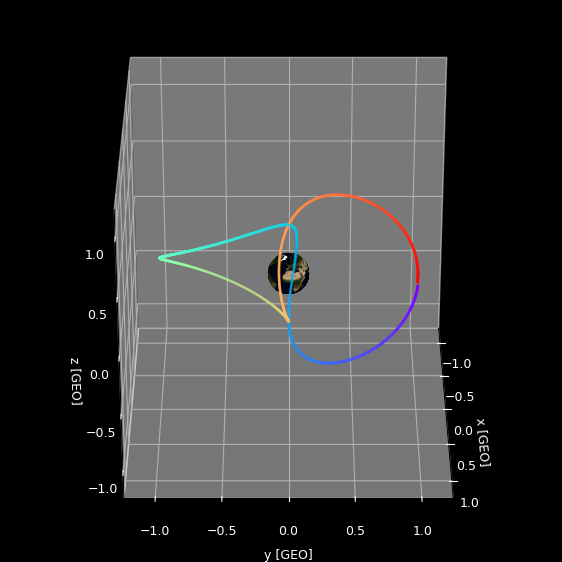

In [3]:
import ssapy
import yeager_utils as ut
import numpy as np
import matplotlib.pyplot as plt

from ssapy.accel import AccelKepler, AccelSolRad, AccelEarthRad, AccelDrag
from ssapy.body import get_body
from ssapy.gravity import AccelThirdBody, AccelHarmonic
kepler = ssapy.RK78Propagator(AccelKepler(), h=10.0)
threebody = ssapy.RK78Propagator(AccelKepler() + AccelThirdBody(get_body("moon")), h=10.0)
high_fidelity = ssapy.RK78Propagator(AccelKepler() + AccelHarmonic(get_body("Earth", model="EGM2008"), 140, 140) + 
    AccelThirdBody(get_body("moon")) + AccelHarmonic(get_body("moon")) + 
    AccelThirdBody(get_body("Sun")) +
    AccelSolRad() + AccelEarthRad(),
    h=10.0
)

props = {'kepler': kepler, 'threebody': threebody, 'high_fidelity': high_fidelity}

times = ut.get_times(duration=(1, 'days'), freq=(1, 'min'), t=ut.Time("2025-1-1"))
r_sun = ssapy.get_body('Sun').position(times).T
r_moon = ssapy.get_body('Moon').position(times).T

sat = dict(
    mass=500,  # [kg] --> was 1e4
    area=.022,  # [m^2]
    CD=2.3,  # Drag coefficient
    CR=1.3,  # Radiation pressure coefficient
)

for name, prop in props.items():
    peri = ut.EARTH_RADIUS + 5000e3
    ap = ut.RGEO
    a = (peri + ap) / 2
    e = (ap - peri)/ (ap + peri)
    r, v = ssapy.rv(ssapy.Orbit.fromKeplerianElements(*[a, e, np.radians(90), 0, 0, np.radians(180)], t=times[0], propkw=sat), times, propagator=prop)
    
    ut.tracking_plot(r, times[:len(r)], title=f"Model: {name}")
    ut.globe_plot(r, times[:len(r)], title=f"Model: {name}")
    plt.show()

# lon, lat, height = ssapy.groundTrack(r, times)


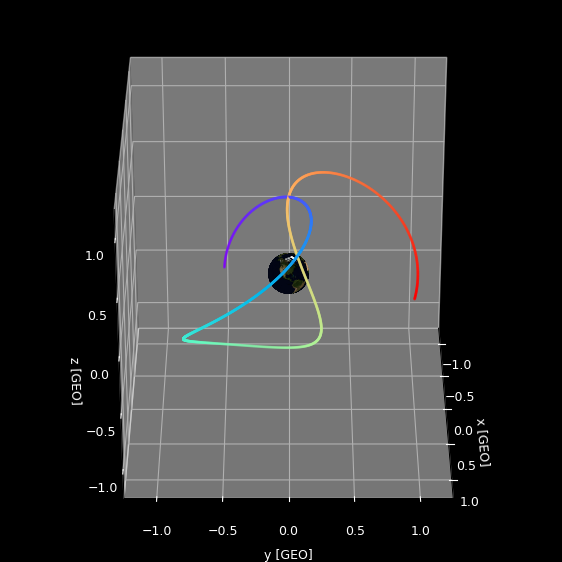

In [4]:
import ssapy
import yeager_utils as ut
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image as PILImage

times = ut.get_times(duration=(1, 'days'), freq=(1, 'min'), t=ut.Time("2025-1-1"))
r_sun = ssapy.get_body('Sun').position(times).T
r_moon = ssapy.get_body('Moon').position(times).T

peri = ut.EARTH_RADIUS + 15000e3
ap = ut.RGEO
a = (peri + ap) / 2
e = (ap - peri)/ (ap + peri)
r, v = ssapy.rv(ssapy.Orbit.fromKeplerianElements(*[a, e, np.radians(90), 0, 0, 0], t=times[0]), times, propagator=ssapy.RK78Propagator(ssapy.AccelKepler(), h=10.0))

r = ut.gcrf_to_itrf(r, times)
x = r[:, 0] / ut.RGEO
y = r[:, 1] / ut.RGEO
z = r[:, 2] / ut.RGEO
limits = np.nanmax(np.abs([x, y, z])) * 1.2

dotcolors = plt.cm.rainbow(np.linspace(0, 1, len(x)))
plt.rcParams.update({'font.size': 9, 'figure.facecolor': 'black'})  # Set background color to black
fig = plt.figure(dpi=100, figsize=(7, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('black')  # Set plot background color to black
earth_png = PILImage.open(ssapy.utils.find_file("earth", ext=".png"))
earth_png = earth_png.resize((5400 // 5, 2700 // 5))
bm = np.array(earth_png.resize([int(d) for d in earth_png.size])) / 256.
lons = np.linspace(-90, 270, bm.shape[1]) * np.pi / 180
lats = np.linspace(-90, 90, bm.shape[0])[::-1] * np.pi / 180
mesh_x = np.outer(np.cos(lons), np.cos(lats)).T * 0.15126911409197252
mesh_y = np.outer(np.sin(lons), np.cos(lats)).T * 0.15126911409197252
mesh_z = np.outer(np.ones(np.size(lons)), np.sin(lats)).T * 0.15126911409197252
ax.scatter(x, y, z, color=dotcolors, s=1)
ax.plot_surface(mesh_x, mesh_y, mesh_z, rstride=4, cstride=4, facecolors=bm, shade=False)
ax.view_init(elev=30, azim=0)
ax.set_xlim([-limits, limits])
ax.set_ylim([-limits, limits])
ax.set_zlim([-limits, limits])
ax.set_xlabel('x [GEO]', color='white')  # Set x-axis label color to white
ax.set_ylabel('y [GEO]', color='white')  # Set y-axis label color to white
ax.set_zlabel('z [GEO]', color='white')  # Set z-axis label color to white
ax.tick_params(axis='x', colors='white')  # Set x-axis tick color to white
ax.tick_params(axis='y', colors='white')  # Set y-axis tick color to white
ax.tick_params(axis='z', colors='white')  # Set z-axis tick color to white
ax.set_aspect('equal')
plt.show(block=True)


In [5]:
from astropy.coordinates import EarthLocation
import astropy.units as u

EarthLocation(
    0 * u.deg, 0 * u.deg, 0 * u.m
).itrs.cartesian.xyz.to(u.m).value

array([6378137.,       0.,       0.])

In [3]:
import yeager_utils as ut
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from IPython.display import clear_output

# Example usage:
v_unit = np.array([1, -1, 1])  # Replace this with your actual unit vector

figs = []
ut.mkdir('/p/lustre1/yeager7/plots_gif/rotate_vector_frames/')
i = 0
for theta in range(0, 361, 10):
    for phi in range(0, 361, 10):
        clear_output(wait=True)
        new_unit_vector = ut.rotate_vector(v_unit, theta, phi, plot=True, save_idx=i)
        i += 1

gif_path = '/p/lustre1/yeager7/plots_gif/rotate_vectors.gif'
ut.write_gif(gif_name=gif_path, frames=ut.sortbynum(ut.listdir('/p/lustre1/yeager7/plots_gif/rotate_vector_frames/*')), fps=5)

Figure saved at: /p/lustre1/yeager7/plots_gif/rotate_vector_frames/1.png
